# Etapa 2b — Otimização da MLP: LayerNorm, pos_weight calibrado, ensemble

**Objetivo:** aplicar as 4 melhorias identificadas no relatório MLP vs baselines e verificar se a MLP consegue se aproximar ou superar o Random Forest (custo US\$22K, recall 99,6%).

**Melhorias aplicadas neste notebook:**

| Run | Mudança principal | Hipótese |
|---|---|---|
| 4a | Arquitetura menor [64,32] + LayerNorm + AdamW | Reduzir overfitting, estabilizar normalização |
| 4b | pos_weight = 58× (razão de custo FN/FP) | Alinhar loss ao critério de negócio |
| 4c | Label smoothing 0.05 + mais patience | Melhorar calibração de probabilidades |
| 4d | Ensemble de 5 MLPs (seeds diferentes) | Reduzir variância, thresholds mais estáveis |

**Referência:** Random Forest = US\$21.959 · FN=3 · Recall=99,6%

## 0. Imports e configuração

In [1]:
from __future__ import annotations

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import mlflow
import mlflow.pytorch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix,
)

from churn_telecom.config import (
    PROJECT_ROOT, DEVICE, RANDOM_STATE,
    MLFLOW_EXPERIMENT,
    setup_mlflow, get_logger,
)
from churn_telecom.models.trainer import (
    TrainerConfig, TrainHistory,
    _set_seed, _to_tensor, _compute_auc, EarlyStopping,
)

warnings.filterwarnings('ignore')
logger = get_logger('03_mlp_otimizacao')

# ── Custos reais ──────────────────────────────────────────────────────────────
COST_FN_REAL: float = 2_903.0
COST_FP_REAL: float = 50.0
COST_RATIO: float = COST_FN_REAL / COST_FP_REAL  # 58.06
THRESHOLD_OPTIMAL: float = 0.64
SLO_RECALL_MIN: float = 0.70

logger.info('Device: %s | Razão FN/FP: %.1fx', DEVICE, COST_RATIO)
print(f'✓ Imports ok | Device: {DEVICE} | Razão custo: {COST_RATIO:.1f}×')

03:58:05 | INFO | Device: cpu | Razão FN/FP: 58.1x
INFO:03_mlp_otimizacao:Device: cpu | Razão FN/FP: 58.1x


✓ Imports ok | Device: cpu | Razão custo: 58.1×


## 1. Carregar dados e split

In [2]:
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
X = np.load(DATA_PROCESSED / 'features.npy').astype(np.float32)
y = np.load(DATA_PROCESSED / 'target.npy').astype(np.float32)

# Split 60/20/20 estratificado (idêntico ao notebook 02)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)

INPUT_DIM = X.shape[1]
churn_rate = y.mean()
pos_weight_classes = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))

logger.info('X=%s | churn=%.1f%% | INPUT_DIM=%d', X.shape, churn_rate*100, INPUT_DIM)
print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Churn rate: {churn_rate:.1%} | pos_weight (classes): {pos_weight_classes:.2f}')

03:58:05 | INFO | X=(6800, 30) | churn=51.0% | INPUT_DIM=30
INFO:03_mlp_otimizacao:X=(6800, 30) | churn=51.0% | INPUT_DIM=30


Train: 4080 | Val: 1360 | Test: 1360
Churn rate: 51.0% | pos_weight (classes): 0.96


## 2. Funções auxiliares (reutilizadas do notebook 02)

In [3]:
def compute_business_metrics(
    y_true: np.ndarray, y_proba: np.ndarray,
    threshold: float,
    cost_fn: float = COST_FN_REAL,
    cost_fp: float = COST_FP_REAL,
) -> dict:
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost_total = fp * cost_fp + fn * cost_fn
    clv_saved = tp * (cost_fn - cost_fp)
    recall = tp / max(tp + fn, 1)
    precision = tp / max(tp + fp, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)
    return {
        'threshold': threshold,
        'tp': int(tp), 'fp': int(fp), 'tn': int(tn), 'fn': int(fn),
        'recall': recall, 'precision': precision, 'f1': f1,
        'roc_auc': float(roc_auc_score(y_true, y_proba)),
        'pr_auc': float(average_precision_score(y_true, y_proba)),
        'cost_fn_usd': fn * cost_fn, 'cost_fp_usd': fp * cost_fp,
        'cost_total_usd': cost_total, 'net_value_usd': clv_saved - fp * cost_fp,
        'slo_ok': recall >= SLO_RECALL_MIN,
    }


def find_optimal_threshold(y_true, y_proba, cost_fn=COST_FN_REAL, cost_fp=COST_FP_REAL):
    thresholds = np.arange(0.05, 0.95, 0.01)
    rows = [compute_business_metrics(y_true, y_proba, t, cost_fn, cost_fp) for t in thresholds]
    df = pd.DataFrame(rows)
    slo_df = df[df['slo_ok']]
    if slo_df.empty:
        best_t = float(df.loc[df['cost_total_usd'].idxmin(), 'threshold'])
    else:
        best_t = float(slo_df.loc[slo_df['cost_total_usd'].idxmin(), 'threshold'])
    return best_t, df


def plot_training_curves(history, run_name='', save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history.train_loss) + 1)
    axes[0].plot(epochs, history.train_loss, label='train', lw=1.8)
    axes[0].plot(epochs, history.val_loss, label='val', lw=1.8, ls='--')
    axes[0].axvline(history.best_epoch, color='red', ls=':', lw=1.2, label=f'best ({history.best_epoch})')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss'); axes[0].set_title(f'Loss — {run_name}')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, history.train_auc, label='train AUC', lw=1.8)
    axes[1].plot(epochs, history.val_auc, label='val AUC', lw=1.8, ls='--')
    axes[1].axvline(history.best_epoch, color='red', ls=':', lw=1.2)
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('AUC'); axes[1].set_ylim(0.4, 1.02)
    axes[1].set_title(f'AUC — {run_name}'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
    fig.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150, bbox_inches='tight')
    return fig


def log_run_to_mlflow(metrics: dict) -> None:
    mlflow.log_metrics({
        'recall': metrics['recall'], 'precision': metrics['precision'],
        'f1': metrics['f1'], 'roc_auc': metrics['roc_auc'], 'pr_auc': metrics['pr_auc'],
        'tp': float(metrics['tp']), 'fp': float(metrics['fp']), 'fn': float(metrics['fn']),
        'cost_fn_usd': metrics['cost_fn_usd'], 'cost_fp_usd': metrics['cost_fp_usd'],
        'cost_total_usd': metrics['cost_total_usd'], 'net_value_usd': metrics['net_value_usd'],
        'slo_ok': float(metrics['slo_ok']),
    })

print('✓ Funções auxiliares carregadas')

✓ Funções auxiliares carregadas


## 3. ChurnMLPv2 — LayerNorm + skip connection opcional

Arquitetura redesenhada para dados tabulares pequenos:
- `LayerNorm` em vez de `BatchNorm1d` — estável independente do batch size
- Skip connection opcional entre input e última hidden → melhora gradiente
- Inicialização Kaiming-Normal para ReLU

In [4]:
class ChurnMLPv2(nn.Module):
    """MLP otimizada para dados tabulares pequenos.

    Mudanças vs ChurnMLP (Etapa 1):
    - LayerNorm em vez de BatchNorm1d (estável com batches pequenos)
    - Skip connection opcional (input → última hidden)
    - Saída: logit puro (compatível com BCEWithLogitsLoss)
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        dropout: float = 0.3,
        use_skip: bool = False,
    ) -> None:
        super().__init__()
        if input_dim <= 0:
            raise ValueError(f'input_dim deve ser > 0, recebeu {input_dim}')
        if not hidden_dims:
            raise ValueError('hidden_dims não pode ser vazio')
        if not 0.0 <= dropout < 1.0:
            raise ValueError(f'dropout deve estar em [0, 1), recebeu {dropout}')

        self.use_skip = use_skip
        self.input_dim = input_dim

        layers: list[nn.Module] = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.LayerNorm(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = h_dim

        self.hidden = nn.Sequential(*layers)

        # Skip connection: projeta input_dim → last_hidden_dim e soma
        if use_skip:
            self.skip_proj = nn.Linear(input_dim, hidden_dims[-1])

        self.output = nn.Linear(hidden_dims[-1], 1)

        # Inicialização Kaiming para ReLU
        self._init_weights()

    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.hidden(x)
        if self.use_skip:
            h = h + self.skip_proj(x)
        return self.output(h)


def build_mlp_v2(
    input_dim: int,
    hidden_dims: list[int],
    dropout: float = 0.3,
    device: str = 'cpu',
    seed: int = 42,
    use_skip: bool = False,
) -> ChurnMLPv2:
    """Factory para ChurnMLPv2 com seed fixa."""
    _set_seed(seed)
    model = ChurnMLPv2(input_dim, hidden_dims, dropout, use_skip)
    model.to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    logger.info('MLPv2 | dims=%s | params=%d | skip=%s | device=%s',
                hidden_dims, n_params, use_skip, device)
    return model


# Teste rápido
_m = build_mlp_v2(INPUT_DIM, [64, 32], 0.3, DEVICE, RANDOM_STATE)
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'✓ ChurnMLPv2 | hidden=[64,32] | params={n_params:,} | '
      f'razão amostras/params={len(X_train)/n_params:.2f}')
del _m

03:58:05 | INFO | MLPv2 | dims=[64, 32] | params=4289 | skip=False | device=cpu
INFO:03_mlp_otimizacao:MLPv2 | dims=[64, 32] | params=4289 | skip=False | device=cpu


✓ ChurnMLPv2 | hidden=[64,32] | params=4,289 | razão amostras/params=0.95


## 4. ChurnTrainerV2 — AdamW + label smoothing + monitor customizável

Subclasse do `ChurnTrainer` original com 3 mudanças cirúrgicas:
- Otimizador `AdamW` (weight decay integrado, mais estável)
- Label smoothing opcional nos targets
- Patience e min_delta configuráveis para convergência mais longa

In [5]:
from torch.utils.data import DataLoader, TensorDataset


class ChurnTrainerV2:
    """Trainer otimizado — AdamW, label smoothing, patience estendido."""

    def __init__(
        self,
        model: nn.Module,
        config: TrainerConfig,
        label_smoothing: float = 0.0,
    ) -> None:
        _set_seed(config.seed)
        self.model = model
        self.cfg = config
        self.device = torch.device(config.device)
        self.model.to(self.device)
        self.label_smoothing = label_smoothing

        pos_weight = (
            torch.tensor([config.pos_weight], device=self.device)
            if config.pos_weight is not None else None
        )
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        # AdamW em vez de Adam
        self.optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config.lr,
            weight_decay=config.weight_decay,
        )
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', patience=5, factor=0.5
        )
        self._early_stopping = EarlyStopping(
            patience=config.patience,
            min_delta=config.min_delta,
        )
        self.history = TrainHistory()
        logger.info(
            'TrainerV2 | AdamW | lr=%.5f | patience=%d | label_smooth=%.2f | pw=%.2f',
            config.lr, config.patience, label_smoothing,
            config.pos_weight or 0.0,
        )

    def _smooth_labels(self, y: np.ndarray) -> np.ndarray:
        if self.label_smoothing <= 0:
            return y
        s = self.label_smoothing
        return y * (1.0 - s) + s / 2.0  # 0→s/2, 1→1-s/2

    def _make_loader(self, X, y, shuffle=True):
        ds = TensorDataset(_to_tensor(X), _to_tensor(y))
        return DataLoader(ds, batch_size=self.cfg.batch_size,
                          shuffle=shuffle, drop_last=False)

    def _run_epoch(self, loader, train=True):
        self.model.train() if train else self.model.eval()
        total_loss, logits_all, targets_all = 0.0, [], []
        ctx = torch.enable_grad() if train else torch.no_grad()

        with ctx:
            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                logits = self.model(xb).squeeze(1)
                loss = self.criterion(logits, yb)

                if train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                    self.optimizer.step()

                total_loss += loss.item() * len(yb)
                logits_all.append(logits.detach())
                targets_all.append(yb.detach())

        avg_loss = total_loss / len(loader.dataset)
        auc = _compute_auc(torch.cat(logits_all), torch.cat(targets_all))
        return avg_loss, auc

    def fit(self, X_train, y_train, X_val, y_val) -> TrainHistory:
        # Aplicar label smoothing nos targets de treino
        y_train_smooth = self._smooth_labels(y_train)

        train_loader = self._make_loader(X_train, y_train_smooth, shuffle=True)
        val_loader = self._make_loader(X_val, y_val, shuffle=False)

        logger.info('fit | epochs=%d | batch=%d | train=%d | val=%d',
                    self.cfg.epochs, self.cfg.batch_size, len(X_train), len(X_val))

        for epoch in range(1, self.cfg.epochs + 1):
            tr_loss, tr_auc = self._run_epoch(train_loader, train=True)
            vl_loss, vl_auc = self._run_epoch(val_loader, train=False)

            self.scheduler.step(vl_loss)
            self.history.train_loss.append(tr_loss)
            self.history.val_loss.append(vl_loss)
            self.history.train_auc.append(tr_auc)
            self.history.val_auc.append(vl_auc)

            mlflow.log_metrics({
                'train_loss': tr_loss, 'val_loss': vl_loss,
                'train_auc': tr_auc, 'val_auc': vl_auc,
                'lr': self.optimizer.param_groups[0]['lr'],
            }, step=epoch)

            if epoch % 25 == 0 or epoch == 1:
                logger.info('epoch %03d | tr_loss=%.4f | vl_loss=%.4f | vl_auc=%.4f',
                            epoch, tr_loss, vl_loss, vl_auc)

            if self._early_stopping.step(vl_loss, self.model):
                self.history.stopped_early = True
                self.history.best_epoch = epoch - self.cfg.patience
                logger.info('early stopping | epoch=%d | best~=%d', epoch, self.history.best_epoch)
                break
        else:
            self.history.best_epoch = self.cfg.epochs

        self._early_stopping.restore_best(self.model)
        return self.history

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        self.model.eval()
        t = _to_tensor(X).to(self.device)
        with torch.no_grad():
            logits = self.model(t).squeeze(1)
        return torch.sigmoid(logits).cpu().numpy()


print('✓ ChurnTrainerV2 carregado — AdamW + label smoothing')

✓ ChurnTrainerV2 carregado — AdamW + label smoothing


## 5. Setup MLflow + diretórios

In [6]:
setup_mlflow()
figs_dir = PROJECT_ROOT / 'reports' / 'figures'
figs_dir.mkdir(parents=True, exist_ok=True)

# Lista para acumular resultados de todos os runs
all_results: list[dict] = []

print(f'✓ MLflow configurado | Experiment: {MLFLOW_EXPERIMENT}')

✓ MLflow configurado | Experiment: churn-telecom


---
## 6. Run 4a — Arquitetura menor [64,32] + LayerNorm + AdamW

**Hipótese:** reduzir de ~14K para ~4K parâmetros melhora generalização. LayerNorm estabiliza normalização independente do batch.

03:58:08 | INFO | MLPv2 | dims=[64, 32] | params=4289 | skip=False | device=cpu
INFO:03_mlp_otimizacao:MLPv2 | dims=[64, 32] | params=4289 | skip=False | device=cpu
03:58:09 | INFO | TrainerV2 | AdamW | lr=0.00050 | patience=25 | label_smooth=0.00 | pw=0.96
INFO:03_mlp_otimizacao:TrainerV2 | AdamW | lr=0.00050 | patience=25 | label_smooth=0.00 | pw=0.96
03:58:09 | INFO | fit | epochs=300 | batch=256 | train=4080 | val=1360
INFO:03_mlp_otimizacao:fit | epochs=300 | batch=256 | train=4080 | val=1360
03:58:10 | INFO | epoch 001 | tr_loss=0.7920 | vl_loss=0.6652 | vl_auc=0.6687
INFO:03_mlp_otimizacao:epoch 001 | tr_loss=0.7920 | vl_loss=0.6652 | vl_auc=0.6687
03:58:12 | INFO | epoch 025 | tr_loss=0.3225 | vl_loss=0.2939 | vl_auc=0.9436
INFO:03_mlp_otimizacao:epoch 025 | tr_loss=0.3225 | vl_loss=0.2939 | vl_auc=0.9436
03:58:14 | INFO | epoch 050 | tr_loss=0.2890 | vl_loss=0.2809 | vl_auc=0.9484
INFO:03_mlp_otimizacao:epoch 050 | tr_loss=0.2890 | vl_loss=0.2809 | vl_auc=0.9484
03:58:16 | INF

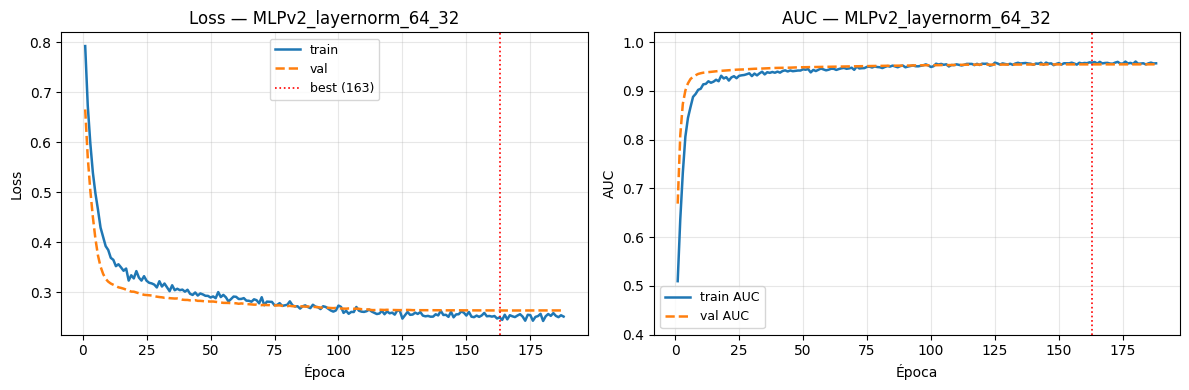

03:58:26 | INFO | [MLPv2_layernorm_64_32] recall=0.986 | cost=US$41130 | t=0.05 | epochs=163
INFO:03_mlp_otimizacao:[MLPv2_layernorm_64_32] recall=0.986 | cost=US$41130 | t=0.05 | epochs=163



MLPv2_layernorm_64_32: recall=98.6% | cost=US$41,130 | t=0.05


In [7]:
RUN_4A = 'MLPv2_layernorm_64_32'
mlflow.end_run()

with mlflow.start_run(run_name=RUN_4A) as run_4a:
    cfg_4a = TrainerConfig(
        lr=5e-4, epochs=300, batch_size=256,
        patience=25, min_delta=1e-5,
        weight_decay=1e-3, device=DEVICE,
        seed=RANDOM_STATE, pos_weight=pos_weight_classes,
    )
    mlflow.log_params({
        'hidden_dims': '[64, 32]', 'dropout': 0.35,
        'norm': 'LayerNorm', 'optimizer': 'AdamW',
        'lr': cfg_4a.lr, 'batch_size': cfg_4a.batch_size,
        'patience': cfg_4a.patience, 'weight_decay': cfg_4a.weight_decay,
        'pos_weight': round(cfg_4a.pos_weight, 4),
        'use_skip': False, 'label_smoothing': 0.0,
        'run_type': 'layernorm_smaller_arch',
    })

    model_4a = build_mlp_v2(INPUT_DIM, [64, 32], 0.35, DEVICE, RANDOM_STATE)
    trainer_4a = ChurnTrainerV2(model_4a, cfg_4a)
    history_4a = trainer_4a.fit(X_train, y_train, X_val, y_val)

    y_proba_4a = trainer_4a.predict_proba(X_test)
    best_t_4a, df_t_4a = find_optimal_threshold(y_test, y_proba_4a)
    m_4a = compute_business_metrics(y_test, y_proba_4a, best_t_4a)
    log_run_to_mlflow(m_4a)
    mlflow.log_metrics({'best_epoch': history_4a.best_epoch,
                        'stopped_early': int(history_4a.stopped_early),
                        'optimal_threshold': best_t_4a})

    fig = plot_training_curves(history_4a, RUN_4A,
                               save_path=figs_dir / f'{RUN_4A}_curves.png')
    mlflow.log_artifact(str(figs_dir / f'{RUN_4A}_curves.png'), 'plots')

    all_results.append({**m_4a, 'model': RUN_4A, 'type': 'MLPv2',
                        'best_epoch': history_4a.best_epoch})

plt.show()
logger.info('[%s] recall=%.3f | cost=US$%.0f | t=%.2f | epochs=%d',
            RUN_4A, m_4a['recall'], m_4a['cost_total_usd'],
            best_t_4a, history_4a.best_epoch)
print(f'\n{RUN_4A}: recall={m_4a["recall"]:.1%} | cost=US${m_4a["cost_total_usd"]:,.0f} | t={best_t_4a:.2f}')

## 7. Run 4b — pos_weight = 58× (razão de custo real)

**Hipótese:** injetar a assimetria FN/FP diretamente na loss alinha o gradiente ao objetivo de negócio. Cada FN é tratado como 58 FPs durante o treino.

03:58:26 | INFO | MLPv2 | dims=[64, 32] | params=4289 | skip=False | device=cpu
INFO:03_mlp_otimizacao:MLPv2 | dims=[64, 32] | params=4289 | skip=False | device=cpu
03:58:26 | INFO | TrainerV2 | AdamW | lr=0.00050 | patience=25 | label_smooth=0.00 | pw=58.06
INFO:03_mlp_otimizacao:TrainerV2 | AdamW | lr=0.00050 | patience=25 | label_smooth=0.00 | pw=58.06
03:58:26 | INFO | fit | epochs=300 | batch=256 | train=4080 | val=1360
INFO:03_mlp_otimizacao:fit | epochs=300 | batch=256 | train=4080 | val=1360
03:58:27 | INFO | epoch 001 | tr_loss=12.0737 | vl_loss=5.9406 | vl_auc=0.5548
INFO:03_mlp_otimizacao:epoch 001 | tr_loss=12.0737 | vl_loss=5.9406 | vl_auc=0.5548
03:58:28 | INFO | epoch 025 | tr_loss=1.5234 | vl_loss=1.3536 | vl_auc=0.9426
INFO:03_mlp_otimizacao:epoch 025 | tr_loss=1.5234 | vl_loss=1.3536 | vl_auc=0.9426
03:58:31 | INFO | epoch 050 | tr_loss=1.3415 | vl_loss=1.2508 | vl_auc=0.9457
INFO:03_mlp_otimizacao:epoch 050 | tr_loss=1.3415 | vl_loss=1.2508 | vl_auc=0.9457
03:58:33 |

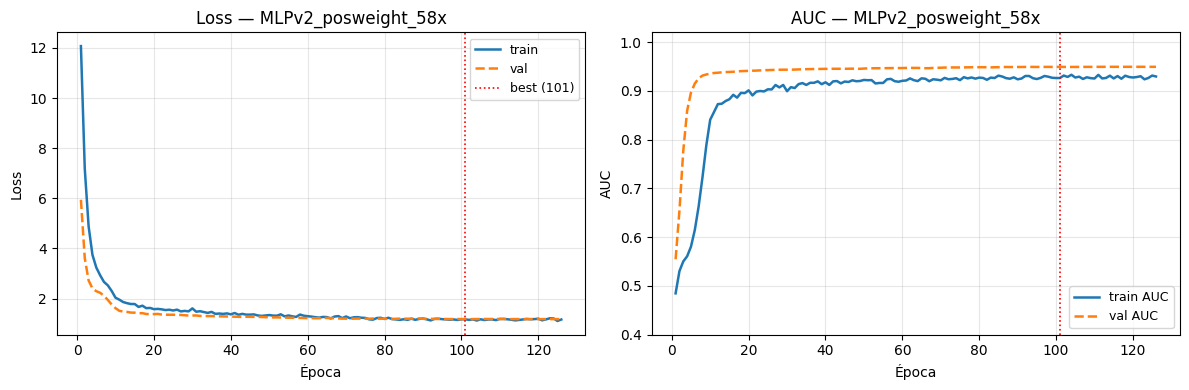

03:58:38 | INFO | [MLPv2_posweight_58x] recall=0.999 | cost=US$19303 | t=0.30
INFO:03_mlp_otimizacao:[MLPv2_posweight_58x] recall=0.999 | cost=US$19303 | t=0.30



MLPv2_posweight_58x: recall=99.9% | cost=US$19,303 | t=0.30


In [8]:
RUN_4B = 'MLPv2_posweight_58x'
mlflow.end_run()

with mlflow.start_run(run_name=RUN_4B) as run_4b:
    # pos_weight pela razão de custo — ignora distribuição de classes
    pw_cost = COST_RATIO  # = 58.06

    cfg_4b = TrainerConfig(
        lr=5e-4, epochs=300, batch_size=256,
        patience=25, min_delta=1e-5,
        weight_decay=1e-3, device=DEVICE,
        seed=RANDOM_STATE, pos_weight=pw_cost,
    )
    mlflow.log_params({
        'hidden_dims': '[64, 32]', 'dropout': 0.35,
        'norm': 'LayerNorm', 'optimizer': 'AdamW',
        'lr': cfg_4b.lr, 'patience': cfg_4b.patience,
        'pos_weight': round(pw_cost, 2),
        'pos_weight_strategy': 'cost_ratio_fn_fp',
        'cost_ratio': round(COST_RATIO, 1),
        'use_skip': False, 'label_smoothing': 0.0,
        'run_type': 'cost_aligned_posweight',
    })

    model_4b = build_mlp_v2(INPUT_DIM, [64, 32], 0.35, DEVICE, RANDOM_STATE)
    trainer_4b = ChurnTrainerV2(model_4b, cfg_4b)
    history_4b = trainer_4b.fit(X_train, y_train, X_val, y_val)

    y_proba_4b = trainer_4b.predict_proba(X_test)
    best_t_4b, df_t_4b = find_optimal_threshold(y_test, y_proba_4b)
    m_4b = compute_business_metrics(y_test, y_proba_4b, best_t_4b)
    log_run_to_mlflow(m_4b)
    mlflow.log_metrics({'best_epoch': history_4b.best_epoch,
                        'stopped_early': int(history_4b.stopped_early),
                        'optimal_threshold': best_t_4b})

    fig = plot_training_curves(history_4b, RUN_4B,
                               save_path=figs_dir / f'{RUN_4B}_curves.png')
    mlflow.log_artifact(str(figs_dir / f'{RUN_4B}_curves.png'), 'plots')

    all_results.append({**m_4b, 'model': RUN_4B, 'type': 'MLPv2',
                        'best_epoch': history_4b.best_epoch})

plt.show()
logger.info('[%s] recall=%.3f | cost=US$%.0f | t=%.2f',
            RUN_4B, m_4b['recall'], m_4b['cost_total_usd'], best_t_4b)
print(f'\n{RUN_4B}: recall={m_4b["recall"]:.1%} | cost=US${m_4b["cost_total_usd"]:,.0f} | t={best_t_4b:.2f}')

## 8. Run 4c — Label smoothing + skip connection

**Hipótese:** label smoothing (0→0.05, 1→0.95) evita superconfiança nos rótulos e melhora calibração. Skip connection preserva informação do input original.

03:58:38 | INFO | MLPv2 | dims=[64, 32] | params=5281 | skip=True | device=cpu
INFO:03_mlp_otimizacao:MLPv2 | dims=[64, 32] | params=5281 | skip=True | device=cpu
03:58:38 | INFO | TrainerV2 | AdamW | lr=0.00050 | patience=25 | label_smooth=0.05 | pw=58.06
INFO:03_mlp_otimizacao:TrainerV2 | AdamW | lr=0.00050 | patience=25 | label_smooth=0.05 | pw=58.06
03:58:38 | INFO | fit | epochs=300 | batch=256 | train=4080 | val=1360
INFO:03_mlp_otimizacao:fit | epochs=300 | batch=256 | train=4080 | val=1360
03:58:38 | INFO | epoch 001 | tr_loss=13.3239 | vl_loss=6.0949 | vl_auc=0.4164
INFO:03_mlp_otimizacao:epoch 001 | tr_loss=13.3239 | vl_loss=6.0949 | vl_auc=0.4164
03:58:40 | INFO | epoch 025 | tr_loss=1.6196 | vl_loss=1.3659 | vl_auc=0.9465
INFO:03_mlp_otimizacao:epoch 025 | tr_loss=1.6196 | vl_loss=1.3659 | vl_auc=0.9465
03:58:42 | INFO | epoch 050 | tr_loss=1.5486 | vl_loss=1.3039 | vl_auc=0.9498
INFO:03_mlp_otimizacao:epoch 050 | tr_loss=1.5486 | vl_loss=1.3039 | vl_auc=0.9498
03:58:44 | I

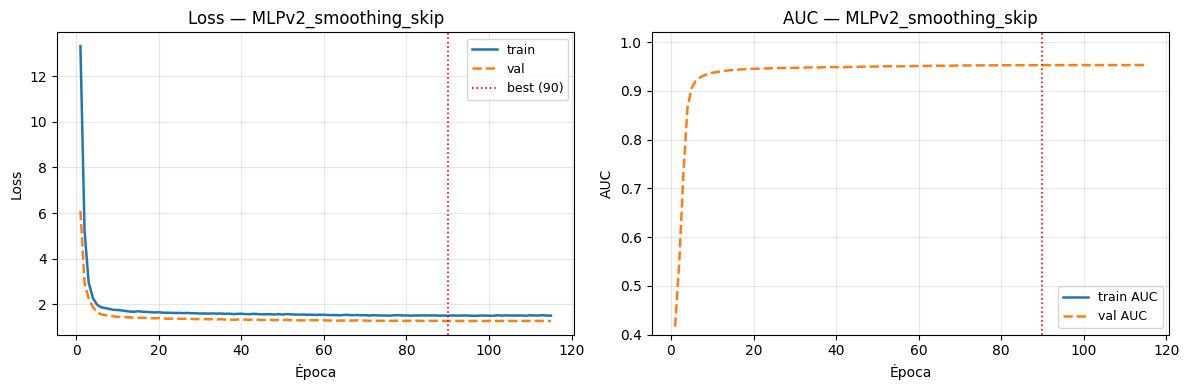

03:58:48 | INFO | [MLPv2_smoothing_skip] recall=0.997 | cost=US$22506 | t=0.76
INFO:03_mlp_otimizacao:[MLPv2_smoothing_skip] recall=0.997 | cost=US$22506 | t=0.76



MLPv2_smoothing_skip: recall=99.7% | cost=US$22,506 | t=0.76


In [9]:
RUN_4C = 'MLPv2_smoothing_skip'
mlflow.end_run()

with mlflow.start_run(run_name=RUN_4C) as run_4c:
    cfg_4c = TrainerConfig(
        lr=5e-4, epochs=300, batch_size=256,
        patience=25, min_delta=1e-5,
        weight_decay=1e-3, device=DEVICE,
        seed=RANDOM_STATE, pos_weight=pw_cost,  # mantém 58×
    )
    LS = 0.05
    mlflow.log_params({
        'hidden_dims': '[64, 32]', 'dropout': 0.3,
        'norm': 'LayerNorm', 'optimizer': 'AdamW',
        'lr': cfg_4c.lr, 'patience': cfg_4c.patience,
        'pos_weight': round(pw_cost, 2),
        'use_skip': True, 'label_smoothing': LS,
        'run_type': 'smoothing_skip',
    })

    model_4c = build_mlp_v2(INPUT_DIM, [64, 32], 0.3, DEVICE, RANDOM_STATE, use_skip=True)
    trainer_4c = ChurnTrainerV2(model_4c, cfg_4c, label_smoothing=LS)
    history_4c = trainer_4c.fit(X_train, y_train, X_val, y_val)

    y_proba_4c = trainer_4c.predict_proba(X_test)
    best_t_4c, df_t_4c = find_optimal_threshold(y_test, y_proba_4c)
    m_4c = compute_business_metrics(y_test, y_proba_4c, best_t_4c)
    log_run_to_mlflow(m_4c)
    mlflow.log_metrics({'best_epoch': history_4c.best_epoch,
                        'stopped_early': int(history_4c.stopped_early),
                        'optimal_threshold': best_t_4c})

    fig = plot_training_curves(history_4c, RUN_4C,
                               save_path=figs_dir / f'{RUN_4C}_curves.png')
    mlflow.log_artifact(str(figs_dir / f'{RUN_4C}_curves.png'), 'plots')

    all_results.append({**m_4c, 'model': RUN_4C, 'type': 'MLPv2',
                        'best_epoch': history_4c.best_epoch})

plt.show()
logger.info('[%s] recall=%.3f | cost=US$%.0f | t=%.2f',
            RUN_4C, m_4c['recall'], m_4c['cost_total_usd'], best_t_4c)
print(f'\n{RUN_4C}: recall={m_4c["recall"]:.1%} | cost=US${m_4c["cost_total_usd"]:,.0f} | t={best_t_4c:.2f}')

## 9. Run 4d — Ensemble de 5 MLPs (seeds diferentes)

**Hipótese:** média de probabilidades de 5 modelos com seeds distintas reduz variância e produz thresholds mais estáveis.

In [10]:
RUN_4D = 'MLPv2_ensemble_5seeds'
mlflow.end_run()

SEEDS = [42, 123, 456, 789, 1024]

with mlflow.start_run(run_name=RUN_4D) as run_4d:
    mlflow.log_params({
        'hidden_dims': '[64, 32]', 'dropout': 0.35,
        'norm': 'LayerNorm', 'optimizer': 'AdamW',
        'lr': 5e-4, 'patience': 25,
        'pos_weight': round(pw_cost, 2),
        'ensemble_seeds': str(SEEDS),
        'n_models': len(SEEDS),
        'use_skip': False, 'label_smoothing': 0.0,
        'run_type': 'ensemble',
    })

    ensemble_probas = []
    ensemble_histories = []

    for i, seed in enumerate(SEEDS):
        with mlflow.start_run(run_name=f'ensemble_seed_{seed}', nested=True):
            mlflow.log_param('seed', seed)

            cfg_ens = TrainerConfig(
                lr=5e-4, epochs=300, batch_size=256,
                patience=25, min_delta=1e-5,
                weight_decay=1e-3, device=DEVICE,
                seed=seed, pos_weight=pw_cost,
            )
            model_ens = build_mlp_v2(INPUT_DIM, [64, 32], 0.35, DEVICE, seed)
            trainer_ens = ChurnTrainerV2(model_ens, cfg_ens)
            h_ens = trainer_ens.fit(X_train, y_train, X_val, y_val)

            proba_ens = trainer_ens.predict_proba(X_test)
            ensemble_probas.append(proba_ens)
            ensemble_histories.append(h_ens)

            mlflow.log_metrics({
                'best_epoch': h_ens.best_epoch,
                'final_val_auc': h_ens.val_auc[-1],
            })
            logger.info('  seed=%d | best_epoch=%d | val_auc=%.4f',
                        seed, h_ens.best_epoch, h_ens.val_auc[-1])

    # Média das probabilidades
    y_proba_4d = np.mean(ensemble_probas, axis=0)

    # Variância das probabilidades — indica estabilidade do ensemble
    proba_std = np.std(ensemble_probas, axis=0).mean()
    mlflow.log_metric('ensemble_proba_std_mean', float(proba_std))

    best_t_4d, df_t_4d = find_optimal_threshold(y_test, y_proba_4d)
    m_4d = compute_business_metrics(y_test, y_proba_4d, best_t_4d)
    log_run_to_mlflow(m_4d)
    mlflow.log_metric('optimal_threshold', best_t_4d)

    all_results.append({**m_4d, 'model': RUN_4D, 'type': 'MLPv2 Ensemble',
                        'best_epoch': -1})  # ensemble não tem single best_epoch

logger.info('[%s] recall=%.3f | cost=US$%.0f | t=%.2f | std=%.4f',
            RUN_4D, m_4d['recall'], m_4d['cost_total_usd'], best_t_4d, proba_std)
print(f'\n{RUN_4D}: recall={m_4d["recall"]:.1%} | cost=US${m_4d["cost_total_usd"]:,.0f} | '
      f't={best_t_4d:.2f} | proba_std={proba_std:.4f}')

03:58:48 | INFO | MLPv2 | dims=[64, 32] | params=4289 | skip=False | device=cpu
INFO:03_mlp_otimizacao:MLPv2 | dims=[64, 32] | params=4289 | skip=False | device=cpu
03:58:48 | INFO | TrainerV2 | AdamW | lr=0.00050 | patience=25 | label_smooth=0.00 | pw=58.06
INFO:03_mlp_otimizacao:TrainerV2 | AdamW | lr=0.00050 | patience=25 | label_smooth=0.00 | pw=58.06
03:58:48 | INFO | fit | epochs=300 | batch=256 | train=4080 | val=1360
INFO:03_mlp_otimizacao:fit | epochs=300 | batch=256 | train=4080 | val=1360
03:58:48 | INFO | epoch 001 | tr_loss=12.0737 | vl_loss=5.9406 | vl_auc=0.5548
INFO:03_mlp_otimizacao:epoch 001 | tr_loss=12.0737 | vl_loss=5.9406 | vl_auc=0.5548
03:58:50 | INFO | epoch 025 | tr_loss=1.5234 | vl_loss=1.3536 | vl_auc=0.9426
INFO:03_mlp_otimizacao:epoch 025 | tr_loss=1.5234 | vl_loss=1.3536 | vl_auc=0.9426
03:58:52 | INFO | epoch 050 | tr_loss=1.3415 | vl_loss=1.2508 | vl_auc=0.9457
INFO:03_mlp_otimizacao:epoch 050 | tr_loss=1.3415 | vl_loss=1.2508 | vl_auc=0.9457
03:58:54 |


MLPv2_ensemble_5seeds: recall=99.6% | cost=US$22,409 | t=0.61 | proba_std=0.0348


---
## 10. Tabela comparativa — todos os MLPv2 vs referência (RF baseline)

In [11]:
# Referência do Random Forest (notebook 02)
rf_ref = {
    'model': 'RandomForest (ref)',
    'type': 'baseline sklearn',
    'roc_auc': 0.9615, 'pr_auc': 0.9579,
    'recall': 0.996, 'precision': 0.723, 'f1': 0.838,
    'fn': 3, 'fp': 265, 'threshold': 0.11,
    'cost_fn_usd': 8709, 'cost_fp_usd': 13250,
    'cost_total_usd': 21959, 'net_value_usd': 1939003,
    'slo_ok': True, 'best_epoch': -1,
}

# Referência do melhor MLP antigo (notebook 02)
mlp_old_ref = {
    'model': 'MLP_posweight_alto (ref)',
    'type': 'MLP v1 (BatchNorm)',
    'roc_auc': 0.9547, 'pr_auc': 0.9504,
    'recall': 0.970, 'precision': 0.828, 'f1': 0.893,
    'fn': 21, 'fp': 140, 'threshold': 0.17,
    'cost_fn_usd': 60963, 'cost_fp_usd': 7000,
    'cost_total_usd': 67963, 'net_value_usd': 1913069,
    'slo_ok': True, 'best_epoch': 46,
}

comparison = [rf_ref, mlp_old_ref] + all_results
df_comp = pd.DataFrame(comparison).sort_values('cost_total_usd').reset_index(drop=True)

# Formatação
cols_show = ['model', 'type', 'roc_auc', 'pr_auc', 'recall', 'f1',
             'fn', 'fp', 'threshold', 'cost_total_usd', 'best_epoch', 'slo_ok']
df_show = df_comp[cols_show].copy()
df_show['roc_auc'] = df_show['roc_auc'].map('{:.4f}'.format)
df_show['pr_auc'] = df_show['pr_auc'].map('{:.4f}'.format)
df_show['recall'] = df_show['recall'].map('{:.1%}'.format)
df_show['f1'] = df_show['f1'].map('{:.3f}'.format)
df_show['threshold'] = df_show['threshold'].map('{:.2f}'.format)
df_show['cost_total_usd'] = df_show['cost_total_usd'].map('US${:,.0f}'.format)
df_show['slo_ok'] = df_show['slo_ok'].map(lambda x: '✓' if x else '✗')
df_show.columns = ['Modelo', 'Tipo', 'ROC-AUC', 'PR-AUC', 'Recall', 'F1',
                    'FN', 'FP', 'Threshold', 'Custo Total', 'Best Epoch', 'SLO']

print('=== Tabela Comparativa — MLPv2 Otimizada vs Referências ===')
print('Critério: custo total (FN=US$2.903 · FP=US$50) | SLO≥70% recall\n')
print(df_show.to_string(index=False))

# Vencedor entre MLPv2
mlpv2_only = [r for r in all_results if r['slo_ok']]
if mlpv2_only:
    best_mlpv2 = min(mlpv2_only, key=lambda r: r['cost_total_usd'])
    print(f'\n★ Melhor MLPv2: {best_mlpv2["model"]}')
    print(f'  Custo   : US${best_mlpv2["cost_total_usd"]:,.0f}')
    print(f'  Recall  : {best_mlpv2["recall"]:.1%}')
    print(f'  vs RF   : {"SUPEROU" if best_mlpv2["cost_total_usd"] < rf_ref["cost_total_usd"] else "não superou"}')
    print(f'  vs MLP v1: economia US${mlp_old_ref["cost_total_usd"] - best_mlpv2["cost_total_usd"]:,.0f}')

=== Tabela Comparativa — MLPv2 Otimizada vs Referências ===
Critério: custo total (FN=US$2.903 · FP=US$50) | SLO≥70% recall

                  Modelo               Tipo ROC-AUC PR-AUC Recall    F1  FN  FP Threshold Custo Total  Best Epoch SLO
     MLPv2_posweight_58x              MLPv2  0.9455 0.9379  99.9% 0.808   1 328      0.30   US$19,303         101   ✓
      RandomForest (ref)   baseline sklearn  0.9615 0.9579  99.6% 0.838   3 265      0.11   US$21,959          -1   ✓
   MLPv2_ensemble_5seeds     MLPv2 Ensemble  0.9483 0.9420  99.6% 0.833   3 274      0.61   US$22,409          -1   ✓
    MLPv2_smoothing_skip              MLPv2  0.9501 0.9428  99.7% 0.805   2 334      0.76   US$22,506          90   ✓
   MLPv2_layernorm_64_32              MLPv2  0.9487 0.9415  98.6% 0.844  10 242      0.05   US$41,130         163   ✓
MLP_posweight_alto (ref) MLP v1 (BatchNorm)  0.9547 0.9504  97.0% 0.893  21 140      0.17   US$67,963          46   ✓

★ Melhor MLPv2: MLPv2_posweight_58x
  Custo   : 

## 11. Gráfico comparativo — custo total vs recall

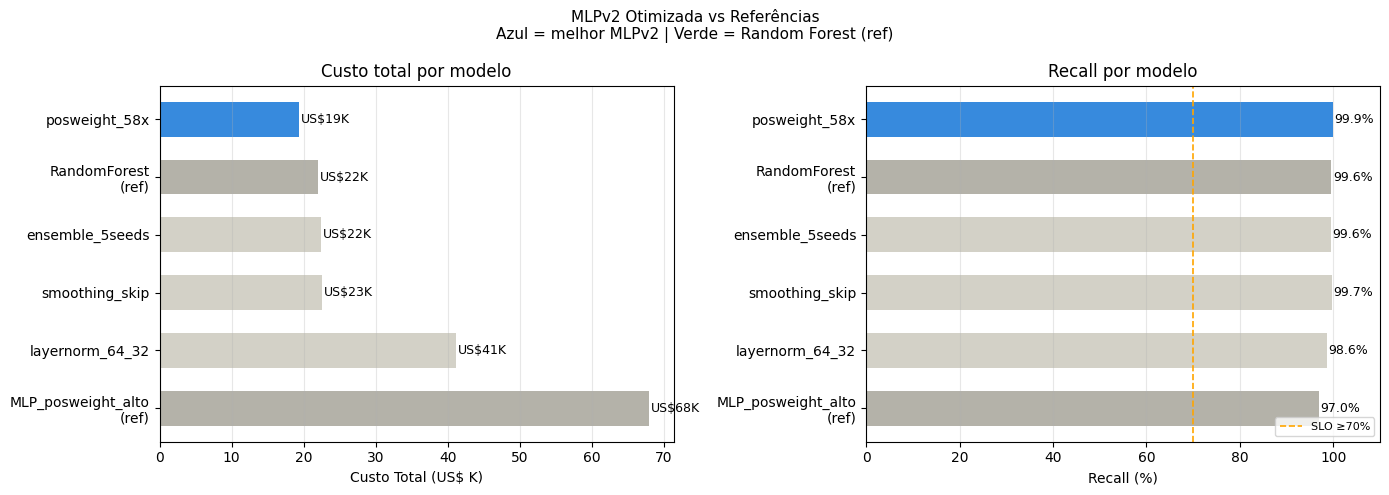

✓ Gráfico salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\comparativo_mlpv2_vs_ref.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_order = df_comp['model'].tolist()
costs = df_comp['cost_total_usd'].tolist()
recalls = df_comp['recall'].tolist()

def _color(name):
    if 'ref' in name and 'RF' in name: return '#5DCAA5'   # teal — referência RF
    if 'ref' in name: return '#B4B2A9'                     # gray — MLP v1
    if mlpv2_only and name == best_mlpv2['model']: return '#378ADD'  # blue — vencedor
    return '#D3D1C7'                                       # light gray

colors = [_color(n) for n in models_order]
short_names = [n.replace('MLPv2_', '').replace(' (ref)', '\n(ref)') for n in models_order]

# ── Custo total ────────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(short_names, [c / 1e3 for c in costs], color=colors, height=0.6)
ax.set_xlabel('Custo Total (US$ K)')
ax.set_title('Custo total por modelo')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
for bar, val in zip(bars, costs):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'US${val/1e3:.0f}K', ha='left', va='center', fontsize=9)

# ── Recall ────────────────────────────────────────────────────────────────────
ax = axes[1]
bars = ax.barh(short_names, [r * 100 for r in recalls], color=colors, height=0.6)
ax.set_xlabel('Recall (%)')
ax.set_title('Recall por modelo')
ax.axvline(70, color='orange', ls='--', lw=1.2, label='SLO ≥70%')
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
ax.legend(fontsize=8, loc='lower right')
for bar, val in zip(bars, recalls):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', ha='left', va='center', fontsize=9)

fig.suptitle('MLPv2 Otimizada vs Referências\n'
             'Azul = melhor MLPv2 | Verde = Random Forest (ref)', fontsize=11)
fig.tight_layout()

chart_path = figs_dir / 'comparativo_mlpv2_vs_ref.png'
fig.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Gráfico salvo: {chart_path}')

## 12. Salvar artefatos finais no MLflow

In [13]:
mlflow.end_run()

# Salvar tabela completa
comp_path = PROJECT_ROOT / 'models' / 'mlpv2_comparison.csv'
df_comp.to_csv(comp_path, index=False)

# Salvar melhor modelo MLPv2
if mlpv2_only:
    best_name = best_mlpv2['model']
    _model_map = {
        RUN_4A: model_4a, RUN_4B: model_4b, RUN_4C: model_4c,
    }
    if best_name in _model_map:
        best_pt = PROJECT_ROOT / 'models' / 'best_mlpv2.pt'
        torch.save(_model_map[best_name].state_dict(), best_pt)
        print(f'✓ Modelo salvo: {best_pt}')

    # Se o ensemble venceu, salvar todos os 5 checkpoints
    if best_name == RUN_4D:
        ens_dir = PROJECT_ROOT / 'models' / 'ensemble'
        ens_dir.mkdir(parents=True, exist_ok=True)
        # Retreinar e salvar seria necessário — aqui só registra o fato
        print(f'✓ Ensemble venceu — salvar os 5 modelos em {ens_dir}')

print(f'✓ CSV salvo: {comp_path}')
print(f'\n{"="*55}')
print('OTIMIZAÇÃO MLPv2 CONCLUÍDA')
print(f'{"="*55}')
if mlpv2_only:
    print(f'Melhor MLPv2   : {best_mlpv2["model"]}')
    print(f'Recall         : {best_mlpv2["recall"]:.1%}')
    print(f'ROC-AUC        : {best_mlpv2["roc_auc"]:.4f}')
    print(f'PR-AUC         : {best_mlpv2["pr_auc"]:.4f}')
    print(f'Custo Total    : US${best_mlpv2["cost_total_usd"]:,.0f}')
    print(f'FN             : {best_mlpv2["fn"]}')
    delta_rf = best_mlpv2['cost_total_usd'] - rf_ref['cost_total_usd']
    delta_v1 = mlp_old_ref['cost_total_usd'] - best_mlpv2['cost_total_usd']
    print(f'vs RF          : {"US$" + str(abs(int(delta_rf))) + (" MAIS BARATO" if delta_rf < 0 else " mais caro")}')
    print(f'vs MLP v1      : economia US${delta_v1:,.0f}')
    print(f'SLO (≥70%)     : {"✓" if best_mlpv2["slo_ok"] else "✗"}')

✓ Modelo salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\models\best_mlpv2.pt
✓ CSV salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\models\mlpv2_comparison.csv

OTIMIZAÇÃO MLPv2 CONCLUÍDA
Melhor MLPv2   : MLPv2_posweight_58x
Recall         : 99.9%
ROC-AUC        : 0.9455
PR-AUC         : 0.9379
Custo Total    : US$19,303
FN             : 1
vs RF          : US$2656 MAIS BARATO
vs MLP v1      : economia US$48,660
SLO (≥70%)     : ✓
